In [4]:
# !git clone https://huggingface.co/datasets/dvrkdvys/SZA_Singing

# EDA test dataset

In [5]:
!pip install soundfile ffmpeg-python

Bắt đầu phân tích...
Bắt đầu quét thư mục: /Users/duongthanhduy/DSP501.22_Assessment/SZA_Singing...
Không tìm thấy 'train/audio', đang quét thư mục gốc: /Users/duongthanhduy/DSP501.22_Assessment/SZA_Singing
Tìm thấy tổng cộng 135 file audio.


Đang phân tích audio: 100%|██████████| 135/135 [00:00<00:00, 4177.01it/s]


--- BÁO CÁO TÓM TẮT DATASET ---
Tổng số file: 135
Tổng thời lượng: 2817.36 giây (~ 46.96 phút)
Thời lượng trung bình: 20.87 giây

Phân phối Tần số Lấy mẫu (Sample Rate):
sample_rate_hz
44100    135
Name: count, dtype: int64

Phân phối Thời lượng (Giây):
count    135.000000
mean      20.869349
std       25.825208
min        1.590567
25%        5.648254
50%       10.623129
75%       24.816327
max      138.634739
Name: duration_seconds, dtype: float64

Đã lưu biểu đồ phân phối thời lượng tại: /Users/duongthanhduy/DSP501.22_Assessment/output/eda_duration_histogram.png


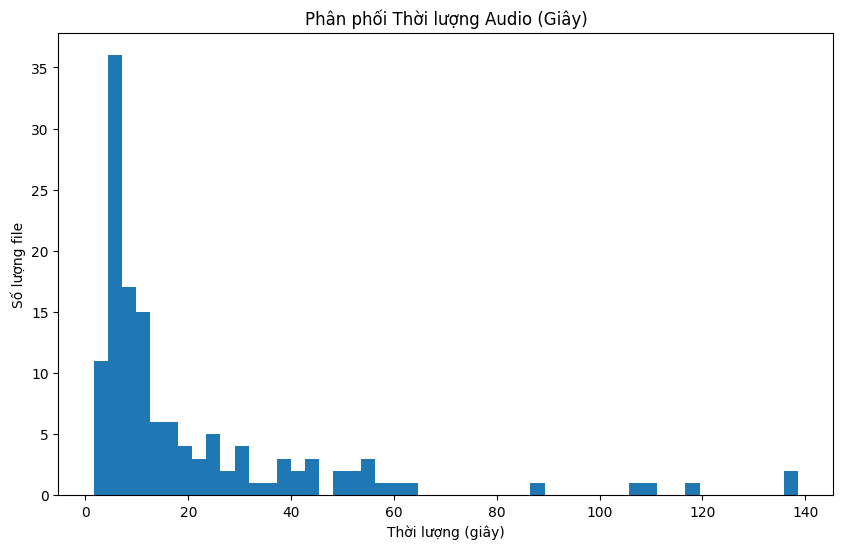

--- Phân tích hoàn tất! ---


In [6]:
import os
import librosa
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings

# --- CÁC HÀM PHÂN TÍCH (Giống như file eda.py) ---

def analyze_dataset(dataset_path):
    """
    Phân tích một thư mục dataset audio.
    Trả về một DataFrame với thông tin file.
    """
    print(f"Bắt đầu quét thư mục: {dataset_path}...")
    audio_files = []

    # Dataset của SZA (dvrkdvys/SZA_Singing) có cấu trúc 'train/audio'
    train_audio_path = os.path.join(dataset_path, 'train', 'audio')

    if os.path.isdir(train_audio_path):
        scan_path = train_audio_path
        print(f"Đã tìm thấy cấu trúc 'train/audio', đang quét: {scan_path}")
    else:
        # Nếu không thấy, thử quét thư mục 'train'
        train_path = os.path.join(dataset_path, 'train')
        if os.path.isdir(train_path):
            scan_path = train_path
            print(f"Đã tìm thấy thư mục 'train', đang quét: {scan_path}")
        else:
            scan_path = dataset_path
            print(f"Không tìm thấy 'train/audio', đang quét thư mục gốc: {scan_path}")

    for root, _, files in os.walk(scan_path):
        for file in files:
            if file.endswith(('.wav', '.flac', '.mp3', '.m4a')):
                file_path = os.path.join(root, file)
                audio_files.append(file_path)

    print(f"Tìm thấy tổng cộng {len(audio_files)} file audio.")

    data = []

    # Tắt cảnh báo của Librosa khi đọc file MP3 (nếu có)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for file_path in tqdm(audio_files, desc="Đang phân tích audio"):
            try:
                # Dùng sr=None để lấy tần số gốc
                sr = librosa.get_samplerate(file_path)
                # Lấy thời lượng
                duration = librosa.get_duration(path=file_path)
                data.append({
                    'file_path': file_path,
                    'duration_seconds': duration,
                    'sample_rate_hz': sr
                })
            except Exception as e:
                # --- SỬA LỖI: IN RA LỖI CHI TIẾT ---
                print(f"\n--- LỖI KHI XỬ LÝ FILE ---")
                print(f"File: {file_path}")
                print(f"Lỗi (e): {e}")
                print(f"Kiểu Lỗi: {type(e)}")
                print(f"----------------------------\n")
                # -----------------------------------

    return pd.DataFrame(data)

def generate_report(df, output_path):
    """
    Tạo báo cáo tóm tắt và lưu biểu đồ.
    """
    if df.empty:
        print("Không có dữ liệu audio để báo cáo.")
        return

    print("\n--- BÁO CÁO TÓM TẮT DATASET ---")

    total_files = len(df)
    total_duration_sec = df['duration_seconds'].sum()
    total_duration_min = total_duration_sec / 60
    mean_duration_sec = df['duration_seconds'].mean()

    print(f"Tổng số file: {total_files}")
    print(f"Tổng thời lượng: {total_duration_sec:.2f} giây (~ {total_duration_min:.2f} phút)")
    print(f"Thời lượng trung bình: {mean_duration_sec:.2f} giây")

    print("\nPhân phối Tần số Lấy mẫu (Sample Rate):")
    print(df['sample_rate_hz'].value_counts())

    print("\nPhân phối Thời lượng (Giây):")
    print(df['duration_seconds'].describe())

    # Vẽ biểu đồ
    # %matplotlib inline (Bạn hãy gõ lệnh này ở một cell riêng)
    plt.figure(figsize=(10, 6))
    df['duration_seconds'].plot(kind='hist', bins=50, title='Phân phối Thời lượng Audio (Giây)')
    plt.xlabel('Thời lượng (giây)')
    plt.ylabel('Số lượng file')

    histogram_path = os.path.join(output_path, 'eda_duration_histogram.png')
    plt.savefig(histogram_path)
    print(f"\nĐã lưu biểu đồ phân phối thời lượng tại: {histogram_path}")
    plt.show() # Hiển thị biểu đồ ngay trong notebook

# --- PHẦN ĐỂ CHẠY TRONG NOTEBOOK ---

# 1. THAY ĐỔI ĐƯỜNG DẪN NÀY:
#    Trỏ đến thư mục dự án của bạn
#    (nơi chứa SZA_Singing, output, v.v.)
#
#    LƯU Ý: Đây là đường dẫn trên MÁY THẬT của bạn.
base_project_path = "/Users/duongthanhduy/DSP501.22_Assessment" # <-- *** THAY ĐỔI NẾU CẦN ***

dataset_path = os.path.join(base_project_path, "SZA_Singing")
output_path = os.path.join(base_project_path, "output")

# Đảm bảo thư mục output tồn tại
os.makedirs(output_path, exist_ok=True)

# --- CHẠY PHÂN TÍCH ---
print("Bắt đầu phân tích...")
df = analyze_dataset(dataset_path)
generate_report(df, output_path)
print("--- Phân tích hoàn tất! ---")